### 라이브러리 임포트

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
from dotenv import load_dotenv
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
import os
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

load_dotenv("../../collect_data/hyerim/.env")
client = MongoClient(os.getenv("MONGO_URI"))
db = client["data_hyerim"]
print("MongoDB 연결 완료")

MongoDB 연결 완료


### 데이터 불러오기

In [2]:
cursor = db["stock_ohlcv_kospi200"].find({}, {"_id": 0})
df = pd.DataFrame(list(cursor))
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["stock_code", "date"]).reset_index(drop=True)

print(f"shape: {df.shape}")
print(f"종목 수: {df['stock_code'].nunique()}")
print(f"기간: {df['date'].min()} ~ {df['date'].max()}")
df.head()

shape: (142249, 12)
종목 수: 121
기간: 2021-06-18 00:00:00 ~ 2026-06-16 00:00:00


,stock_code,date,close,collected_at,high,interval,low,open,source,trade_value,volume,stock_name
0,000100,2021-06-18,56077,2026-06-17 13:19:34.836,56077,1day,55200,55463,kis,18207998900,326757,유한양행
1,000100,2021-06-21,55376,2026-06-17 13:19:34.835,55551,1day,54938,55463,kis,16939607700,307332,유한양행
2,000100,2021-06-22,55463,2026-06-17 13:19:34.835,55726,1day,55200,55288,kis,8127657700,146688,유한양행
3,000100,2021-06-23,55025,2026-06-17 13:19:34.835,55639,1day,54938,55551,kis,15206258700,275885,유한양행
4,000100,2021-06-24,55288,2026-06-17 13:19:34.835,55463,1day,55025,55200,kis,9393488600,169991,유한양행


### 삼성전자 피처 계산

In [3]:
df_ss = df[df["stock_code"] == "005930"].copy().sort_values("date").reset_index(drop=True)

# 이동평균선
for w in [5, 10, 20, 60, 120]:
    df_ss[f"ma{w}"] = df_ss["close"].rolling(w).mean()

# 볼린저밴드
df_ss["bb_mid"]   = df_ss["close"].rolling(20).mean()
df_ss["bb_std"]   = df_ss["close"].rolling(20).std()
df_ss["bb_upper"] = df_ss["bb_mid"] + 2 * df_ss["bb_std"]
df_ss["bb_lower"] = df_ss["bb_mid"] - 2 * df_ss["bb_std"]
df_ss["bb_pct"]   = (df_ss["close"] - df_ss["bb_lower"]) / (df_ss["bb_upper"] - df_ss["bb_lower"])

# 거래량 급등비율
df_ss["vol_ratio"] = df_ss["volume"] / df_ss["volume"].rolling(20).mean()

# 60일선 괴리율
df_ss["ma60_gap"] = (df_ss["close"] - df_ss["ma60"]) / df_ss["ma60"]

# 정배열 여부
df_ss["is_uptrend"] = (
    (df_ss["ma5"] > df_ss["ma10"]) &
    (df_ss["ma10"] > df_ss["ma20"]) &
    (df_ss["ma20"] > df_ss["ma60"])
).astype(int)

# 캔들 몸통 비율
df_ss["body_ratio"] = abs(df_ss["close"] - df_ss["open"]) / (df_ss["high"] - df_ss["low"] + 1)

# 미래 수익률 (5일 후)
df_ss["future_return"] = df_ss["close"].shift(-5) / df_ss["close"] - 1

# Y 라벨: 5일 후 2% 이상 상승이면 1
df_ss["target"] = (df_ss["future_return"] > 0.02).astype(int)

df_ss = df_ss.dropna().reset_index(drop=True)
print(f"피처 계산 완료: {df_ss.shape}")
print(f"target 분포:\n{df_ss['target'].value_counts()}")
df_ss.head()

피처 계산 완료: (1097, 28)
target 분포:
target
0    736
1    361
Name: count, dtype: int64


,stock_code,date,close,collected_at,high,interval,low,open,source,trade_value,...,bb_std,bb_upper,bb_lower,bb_pct,vol_ratio,ma60_gap,is_uptrend,body_ratio,future_return,target
0,005930,2021-12-10,76900,2026-06-17 11:40:43.133,77600,1day,76800,77400,kis,705966272740,...,2553.037407,79176.074813,68963.925187,0.777121,0.528983,0.056657,1,0.624220,0.014304,0
1,005930,2021-12-13,76800,2026-06-17 11:40:43.133,78300,1day,76500,77200,kis,1163285000550,...,2541.321662,79422.643324,69257.356676,0.742000,0.862407,0.055162,1,0.222099,0.003906,0
2,005930,2021-12-14,77000,2026-06-17 11:40:43.133,77200,1day,76200,76500,kis,841446671988,...,2501.762537,79628.525073,69621.474927,0.737333,0.629360,0.057813,1,0.499500,0.014286,0
3,005930,2021-12-15,77600,2026-06-17 11:40:43.133,77600,1day,76300,76400,kis,738591816100,...,2405.935642,79781.871285,70158.128715,0.773282,0.551847,0.065910,1,0.922367,0.023196,1
4,005930,2021-12-16,77800,2026-06-17 11:40:43.133,78500,1day,77400,78500,kis,934244160164,...,2204.660136,79759.320272,70940.679728,0.777821,0.687008,0.068241,1,0.635786,0.026992,1


### 상관계수로 피처 중요도 확인

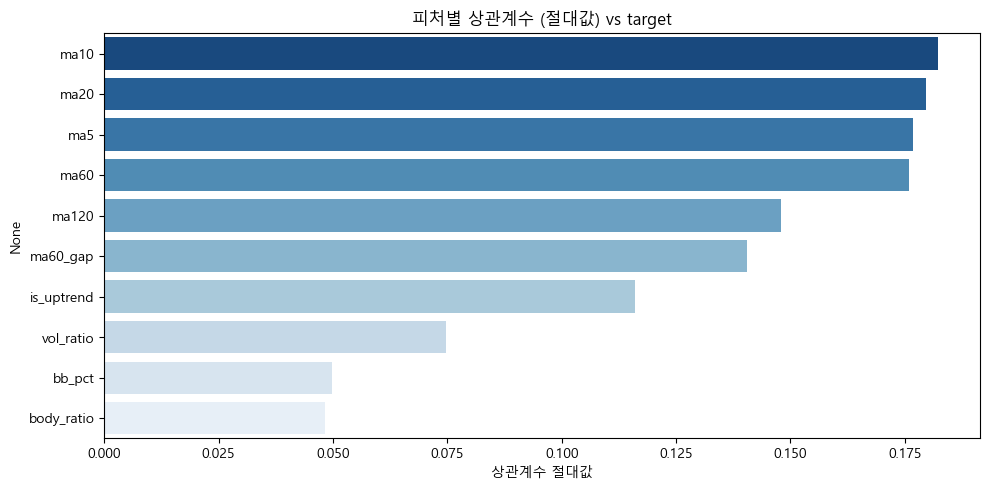

ma10          0.182358
ma20          0.179721
ma5           0.176753
ma60          0.176020
ma120         0.148011
ma60_gap      0.140472
is_uptrend    0.115989
vol_ratio     0.074629
bb_pct        0.049774
body_ratio    0.048257
Name: target, dtype: float64


In [4]:
feature_cols = ["ma5","ma10","ma20","ma60","ma120",
                "bb_pct","vol_ratio","ma60_gap","is_uptrend","body_ratio"]

corr_result = df_ss[feature_cols + ["target"]].corr()["target"].abs().drop("target").sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=corr_result.values, y=corr_result.index, palette="Blues_r")
plt.title("피처별 상관계수 (절대값) vs target")
plt.xlabel("상관계수 절대값")
plt.tight_layout()
plt.show()
print(corr_result)

### Mutual Information으로 비선형 중요도 확인

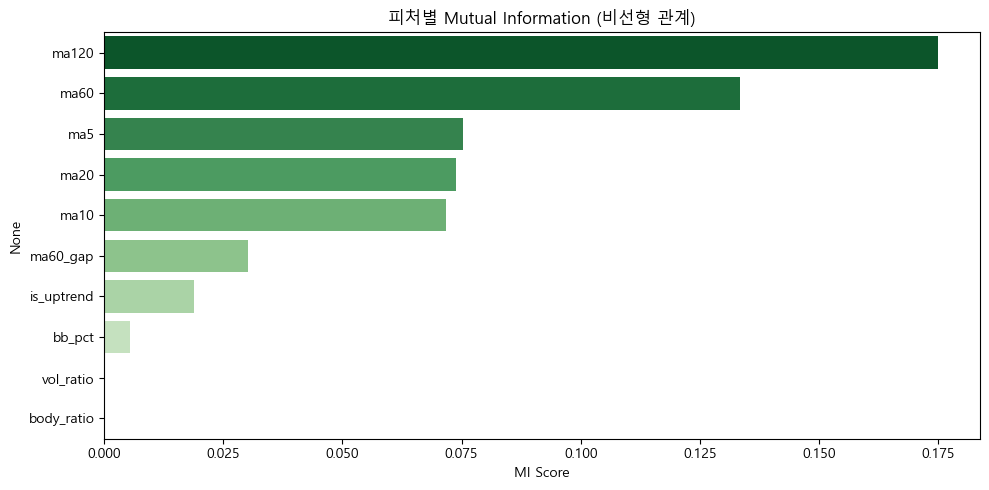

ma120         0.175076
ma60          0.133355
ma5           0.075280
ma20          0.073827
ma10          0.071639
ma60_gap      0.030214
is_uptrend    0.018927
bb_pct        0.005338
vol_ratio     0.000000
body_ratio    0.000000
dtype: float64


In [5]:
X = df_ss[feature_cols]
y = df_ss["target"]

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_result = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=mi_result.values, y=mi_result.index, palette="Greens_r")
plt.title("피처별 Mutual Information (비선형 관계)")
plt.xlabel("MI Score")
plt.tight_layout()
plt.show()
print(mi_result)

### RandomForest Feature Importance

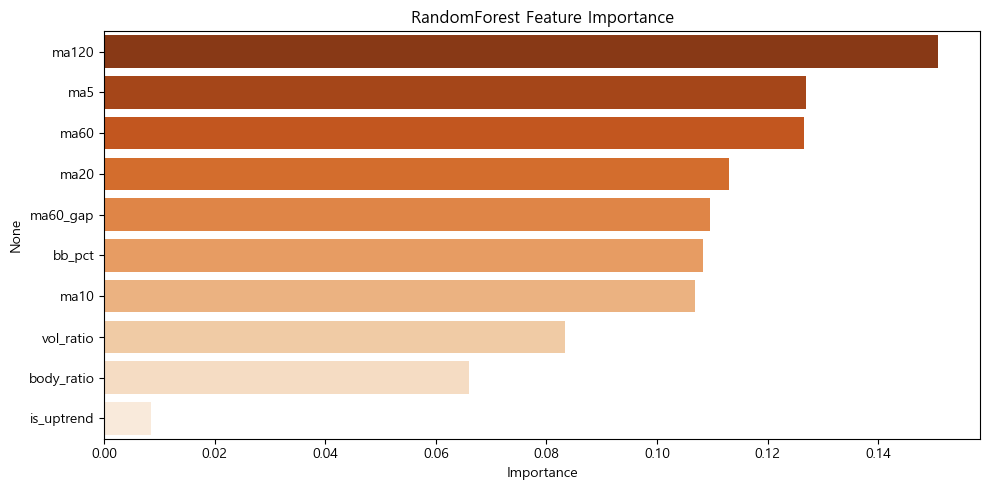

ma120         0.150891
ma5           0.126920
ma60          0.126654
ma20          0.113109
ma60_gap      0.109532
bb_pct        0.108297
ma10          0.106805
vol_ratio     0.083307
body_ratio    0.066021
is_uptrend    0.008464
dtype: float64


In [6]:
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X, y)

rf_importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=rf_importance.values, y=rf_importance.index, palette="Oranges_r")
plt.title("RandomForest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
print(rf_importance)

### 세 가지 종합 점수 히트맵

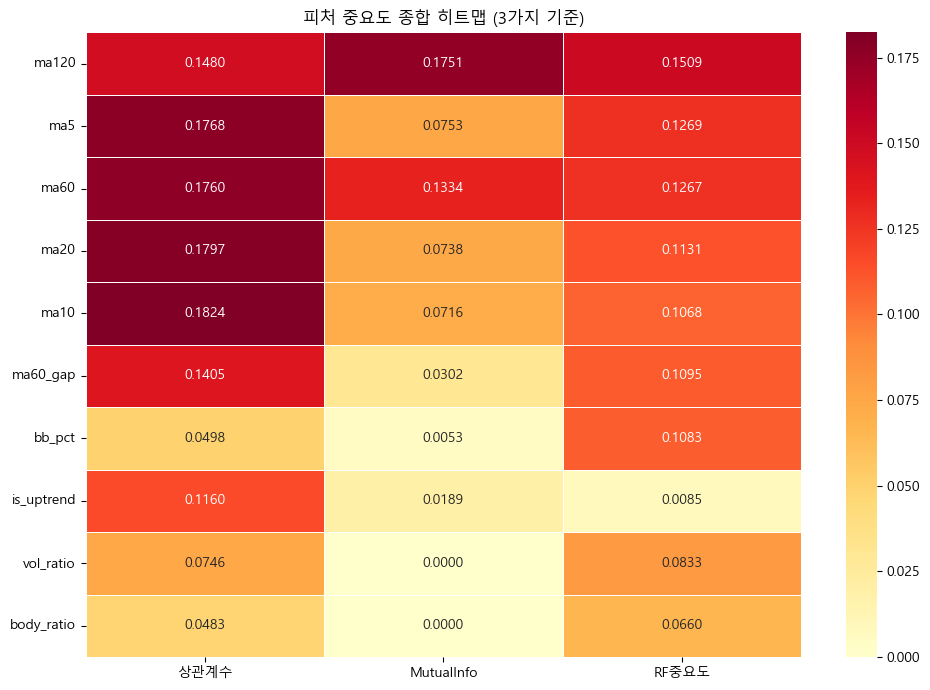


최종 피처 우선순위:
              총점
ma120       26.0
ma5         25.0
ma60        24.0
ma20        23.0
ma10        20.0
ma60_gap    16.0
bb_pct      10.0
is_uptrend   9.0
vol_ratio    7.5
body_ratio   4.5


In [7]:
importance_df = pd.DataFrame({
    "상관계수":    corr_result,
    "MutualInfo":  mi_result,
    "RF중요도":    rf_importance,
})

# 각 기준 순위 합산
importance_df["총점"] = (
    importance_df["상관계수"].rank() +
    importance_df["MutualInfo"].rank() +
    importance_df["RF중요도"].rank()
)
importance_df = importance_df.sort_values("총점", ascending=False)

plt.figure(figsize=(10, 7))
sns.heatmap(
    importance_df[["상관계수","MutualInfo","RF중요도"]],
    annot=True, fmt=".4f", cmap="YlOrRd",
    linewidths=0.5
)
plt.title("피처 중요도 종합 히트맵 (3가지 기준)")
plt.tight_layout()
plt.show()

print("\n최종 피처 우선순위:")
print(importance_df[["총점"]])

### 상위 피처 간 상관관계 히트맵

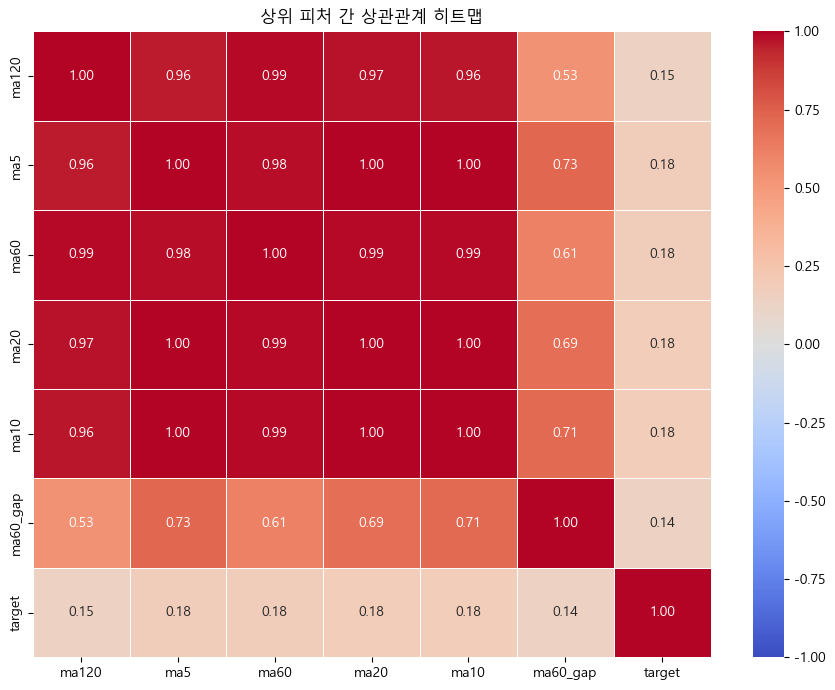

In [8]:
top_features = importance_df.index[:6].tolist()

plt.figure(figsize=(9, 7))
sns.heatmap(
    df_ss[top_features + ["target"]].corr(),
    annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, linewidths=0.5
)
plt.title("상위 피처 간 상관관계 히트맵")
plt.tight_layout()
plt.show()

- 결과 해석: 이동평균선끼리(ma5/ma10/ma20/ma60/ma120) 서로 0.96-1.00으로 거의 동일한 정보를 담고 있다. 다중공선성 문제가 있어서 모두 넣으면 모델에 부담이 됩니다. ma60_gap이 상대적으로 독립적(0.53-0.73)이라 이평선 중에서는 ma60_gap 하나가 대표성이 높다.

### target별 피처 분포 (boxplot)

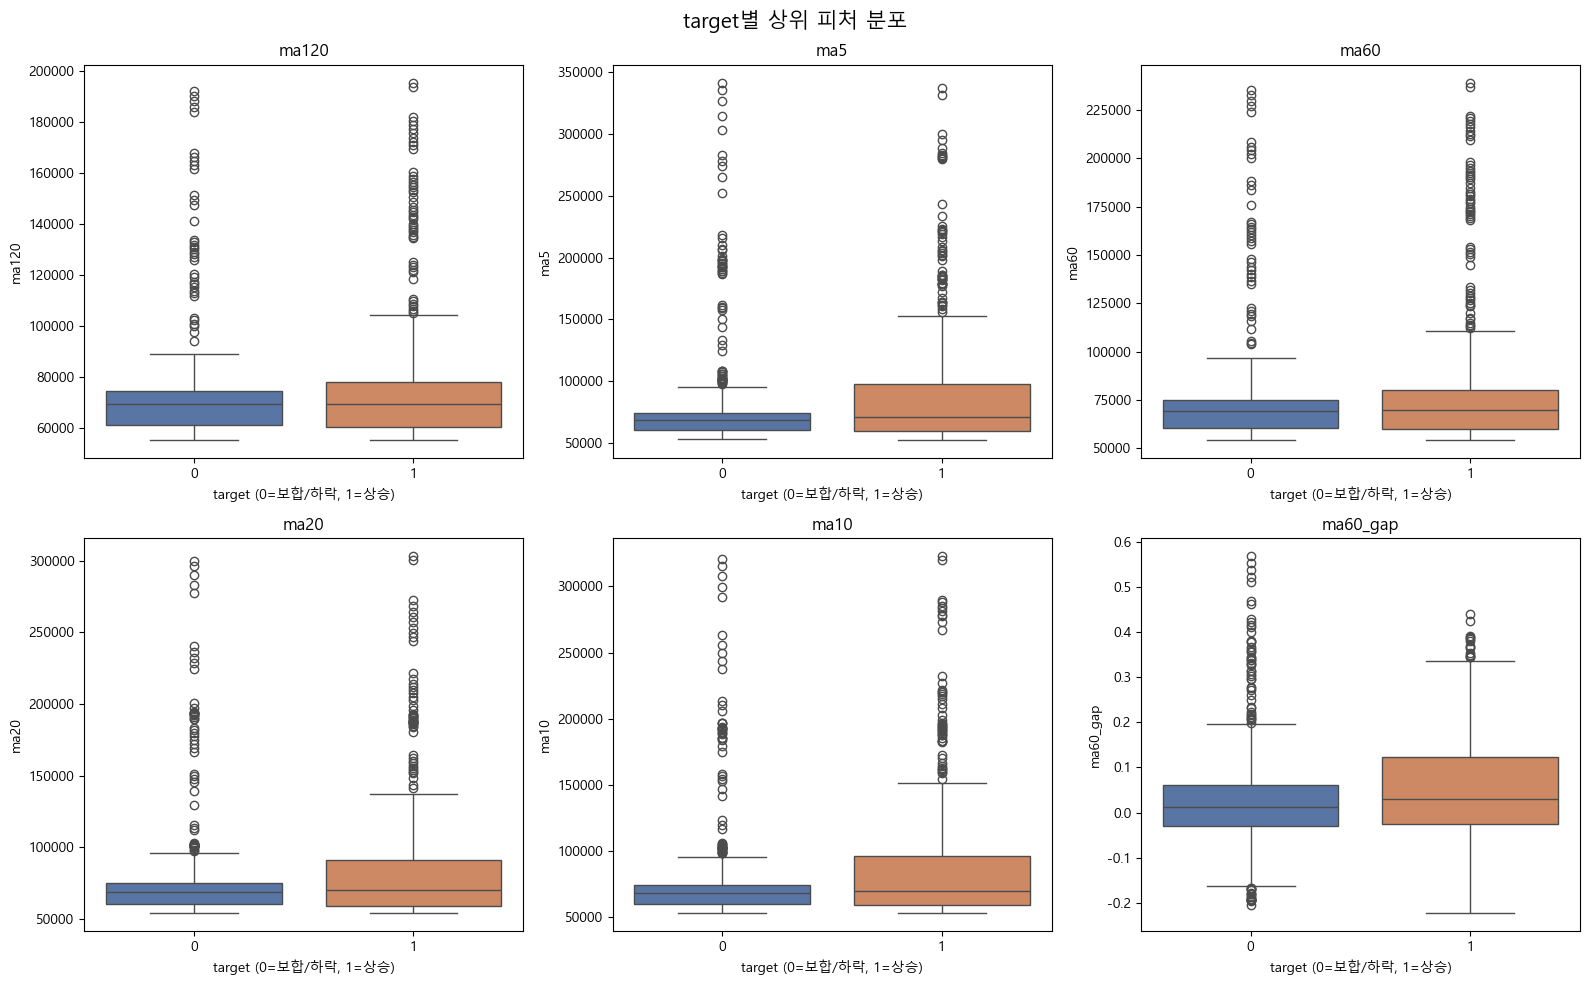

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, col in zip(axes.flatten(), top_features):
    sns.boxplot(data=df_ss, x="target", y=col, ax=ax, palette=["#4C72B0","#DD8452"])
    ax.set_title(col)
    ax.set_xlabel("target (0=보합/하락, 1=상승)")

plt.suptitle("target별 상위 피처 분포", fontsize=15)
plt.tight_layout()
plt.show()